# Exercise 1 — Gray-Level Transformation

Student: Konstantinos Kritsotakis

Registration Number: 7115152500007  

Course: Image Analysis and Processing (2025–2026) 

## (a) Effect of the transformation function on a grayscale image

The given transformation function maps each input gray-level value r to an output gray-level value s = T(r). From the graph, the transformation is a piecewise constant, or step-like, function.

The transformation groups many input intensity values into only 8 output gray levels:

{10, 20, 50, 70, 100, 140, 180, 200}

Therefore, the transformation performs gray-level quantization. Fine intensity variations inside each interval are lost, while sudden intensity jumps appear between intervals. As a result, the transformed image becomes less smooth and shows a posterization effect.

## (b) Verification by applying the transformation to an image

To verify the theoretical analysis, the transformation function was applied to a grayscale image.  
The implementation uses a lookup table \(T\), where each possible input intensity value \(r \in [0,255]\) is mapped to its corresponding output value \(T(r)\).  

The original image, the transformed image, their histograms, and numerical measurements are shown below.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, img_as_ubyte

image_path = r"C:\Users\Konstantinos Krit\Desktop\MSc\Β' Εξάμηνο\Image Analysis & Processing\1st Project\image_1.jpg"

img = io.imread(image_path)

if img.ndim == 3:
    img = color.rgb2gray(img)
    img = img_as_ubyte(img)
else:
    img = img.astype(np.uint8)

In [7]:
T = np.zeros(256, dtype=np.uint8)

T[0:30]    = 10
T[30:60]   = 20
T[60:90]   = 50
T[90:120]  = 70
T[120:160] = 100
T[160:190] = 140
T[190:220] = 180
T[220:256] = 200

transformed = T[img]

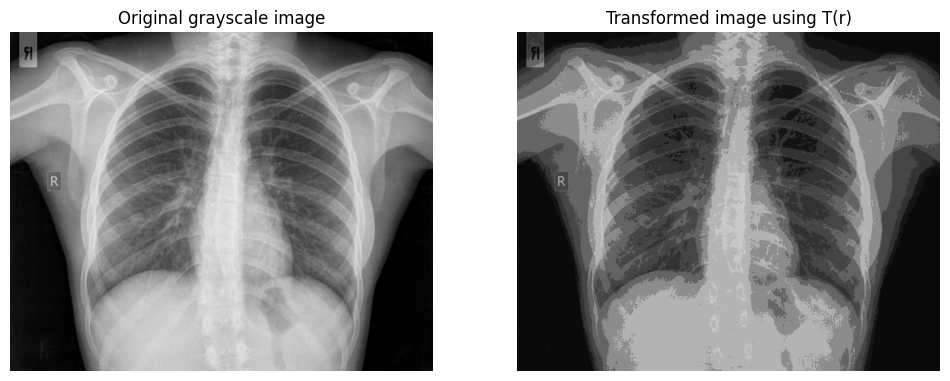

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original grayscale image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(transformed, cmap='gray', vmin=0, vmax=255)
plt.title("Transformed image using T(r)")
plt.axis("off")

plt.show()

The transformed image appears less smooth than the original image. This happens because many different input intensity values are mapped to the same output gray level. Therefore, fine gray-level variations are lost and visible intensity bands appear.

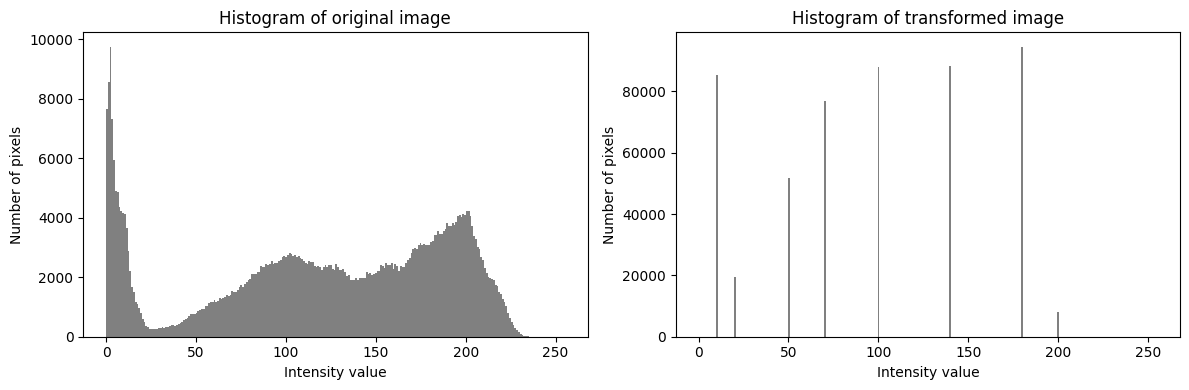

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(img.ravel(), bins=256, range=(0, 255), color='gray')
plt.title("Histogram of original image")
plt.xlabel("Intensity value")
plt.ylabel("Number of pixels")

plt.subplot(1, 2, 2)
plt.hist(transformed.ravel(), bins=256, range=(0, 255), color='gray')
plt.title("Histogram of transformed image")
plt.xlabel("Intensity value")
plt.ylabel("Number of pixels")

plt.tight_layout()
plt.show()

The original histogram is distributed over many intensity values. In contrast, the transformed histogram contains only 8 peaks, corresponding to the 8 possible output gray levels of the transformation function.

In [10]:
print("Original image:")
print("Minimum intensity:", img.min())
print("Maximum intensity:", img.max())
print("Dynamic range:", int(img.max()) - int(img.min()))
print("Number of different gray levels:", len(np.unique(img)))

print("\nTransformed image:")
print("Minimum intensity:", transformed.min())
print("Maximum intensity:", transformed.max())
print("Dynamic range:", int(transformed.max()) - int(transformed.min()))
print("Different gray levels:", np.unique(transformed))
print("Number of different gray levels:", len(np.unique(transformed)))

test_values = np.array([0, 29, 30, 59, 60, 89, 90, 119, 120, 155, 160, 189, 190, 219, 220, 255])

print("\nExample mappings r -> T(r):")
for r in test_values:
    print(f"{r:3d} -> {T[r]}")

Original image:
Minimum intensity: 0
Maximum intensity: 240
Dynamic range: 240
Number of different gray levels: 241

Transformed image:
Minimum intensity: 10
Maximum intensity: 200
Dynamic range: 190
Different gray levels: [ 10  20  50  70 100 140 180 200]
Number of different gray levels: 8

Example mappings r -> T(r):
  0 -> 10
 29 -> 10
 30 -> 20
 59 -> 20
 60 -> 50
 89 -> 50
 90 -> 70
119 -> 70
120 -> 100
155 -> 100
160 -> 140
189 -> 140
190 -> 180
219 -> 180
220 -> 200
255 -> 200


The numerical results confirm the theoretical analysis. The original image contains many gray levels, while the transformed image contains only 8 gray levels: 10, 20, 50, 70, 100, 140, 180 and 200.

The dynamic range is also reduced. Therefore, the transformation performs gray-level quantization, removes fine intensity variations, creates abrupt intensity transitions between intervals, and produces a posterization effect.

## Final conclusion

The results confirm the theoretical interpretation of the transformation function.  
The original image contains many different gray levels and smooth intensity transitions.  
After the transformation, the image contains only 8 gray levels: 10, 20, 50, 70, 100, 140, 180 and 200.

Therefore, the transformation reduces the number of gray levels, decreases the dynamic range, removes fine intensity variations inside each interval, and creates abrupt transitions between intervals. This produces a gray-level quantization / posterization effect.